# **Infiltration and Soil Water Retention**

How water enters the soil and how much of it the soil can hold: Green-Ampt infiltration and the van Genuchten retention curve.

## **Learning objectives**

By the end of this tutorial you will be able to:

- Describe infiltration capacity and why it declines during a storm.
- Implement the Green-Ampt model with ponding time for a constant-intensity storm.
- Plot van Genuchten water retention and hydraulic conductivity curves for different soil textures.
- Compute field capacity, wilting point, and plant-available water from retention parameters.

**Before you start:** No data files are needed; everything is computed from textbook parameters.

## **Green-Ampt infiltration**

Green and Ampt (1911) pictured infiltration as a sharp wetting front moving down into the soil. With ponded water at
the surface, the infiltration capacity $f$ (rate at which the soil *can* take water) is

$$ f = K_s \left( 1 + \frac{\psi_f \, \Delta\theta}{F} \right) \qquad (1) $$

where $K_s$ is saturated hydraulic conductivity, $\psi_f$ is the wetting-front suction head, $\Delta\theta = \theta_s - \theta_i$
is the change in water content across the front, and $F$ is cumulative infiltration. Early in a storm $F$ is small and $f$ is
large; as the front moves down, $f$ falls toward $K_s$.

For rain of constant intensity $i$, water infiltrates at the rain rate until the soil's capacity drops to $i$. That moment is
the **ponding time** $t_p$:

$$ F_p = \frac{K_s \, \psi_f \, \Delta\theta}{i - K_s}, \qquad t_p = \frac{F_p}{i} \qquad (2) $$

After ponding, cumulative infiltration follows the implicit equation

$$ F - \psi_f \Delta\theta \, \ln\!\left(1 + \frac{F}{\psi_f \Delta\theta}\right) = K_s \,(t - t_p) + F_p - \psi_f \Delta\theta \, \ln\!\left(1 + \frac{F_p}{\psi_f \Delta\theta}\right) \qquad (3) $$

which we solve numerically. Rain that cannot infiltrate becomes **infiltration-excess runoff**.

## **Water retention: van Genuchten (1980)**

How much water a soil holds at a given suction $h$ (matric head) is described by the retention curve:

$$ \theta(h) = \theta_r + \frac{\theta_s - \theta_r}{\left[1 + (\alpha |h|)^n\right]^{m}}, \qquad m = 1 - \frac{1}{n} \qquad (4) $$

and the unsaturated hydraulic conductivity (Mualem-van Genuchten):

$$ K(S_e) = K_s \, S_e^{\,l} \left[1 - \left(1 - S_e^{1/m}\right)^{m}\right]^2, \qquad S_e = \frac{\theta - \theta_r}{\theta_s - \theta_r} \qquad (5) $$

with $l = 0.5$. **Field capacity** is often taken at $h = -330$ cm (or $-100$ cm for coarse soils) and **wilting point** at
$h = -15{,}000$ cm; the difference is the **plant-available water**.

## **Setup: packages and data**

The cell below loads the packages we need and defines a small helper that finds the sample data. If you are running inside the cloned repository it uses the local `sample_data/` folder; on Google Colab it downloads the files from GitHub.

In [1]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 100

BASE = "https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/sample_data/"

def get_data(fname):
    """Return a local path to a sample data file, downloading it from GitHub if needed."""
    for local in [os.path.join('..', '..', 'sample_data', fname), os.path.join('sample_data', fname)]:
        if os.path.exists(local):
            return local
    os.makedirs('sample_data', exist_ok=True)
    out = os.path.join('sample_data', fname)
    urllib.request.urlretrieve(BASE + fname, out)
    return out

files = []
paths = {f: get_data(f) for f in files}
paths

{}

## **Step 1: Soil parameters**

Typical values from Carsel and Parrish (1988) for the van Genuchten model, and Rawls et al. (1983) for Green-Ampt.

In [2]:
# van Genuchten parameters: theta_r, theta_s, alpha (1/cm), n, Ks (cm/day)
vg = pd.DataFrame({
    'sand':       [0.045, 0.43, 0.145, 2.68, 712.8],
    'loamy sand': [0.057, 0.41, 0.124, 2.28, 350.2],
    'sandy loam': [0.065, 0.41, 0.075, 1.89, 106.1],
    'loam':       [0.078, 0.43, 0.036, 1.56,  24.96],
    'silt loam':  [0.067, 0.45, 0.020, 1.41,  10.8],
    'clay loam':  [0.095, 0.41, 0.019, 1.31,   6.24],
    'clay':       [0.068, 0.38, 0.008, 1.09,   4.8],
}, index=['theta_r', 'theta_s', 'alpha', 'n', 'Ks']).T
# Green-Ampt parameters (Rawls et al., 1983): psi_f (cm), Ks (cm/h), theta_s (porosity)
ga = pd.DataFrame({
    'sand':       [4.95, 11.78, 0.437],
    'sandy loam': [11.01, 1.09, 0.453],
    'loam':       [8.89, 0.34, 0.463],
    'silt loam':  [16.68, 0.65, 0.501],
    'clay loam':  [20.88, 0.10, 0.464],
    'clay':       [31.63, 0.03, 0.475],
}, index=['psi_f', 'Ks', 'theta_s']).T
vg.round(3)

,theta_r,theta_s,alpha,n,Ks
sand,0.045,0.43,0.145,2.68,712.80
loamy sand,0.057,0.41,0.124,2.28,350.20
sandy loam,0.065,0.41,0.075,1.89,106.10
loam,0.078,0.43,0.036,1.56,24.96
silt loam,0.067,0.45,0.020,1.41,10.80
clay loam,0.095,0.41,0.019,1.31,6.24
clay,0.068,0.38,0.008,1.09,4.80


## **Step 2: Green-Ampt for a constant-intensity storm**

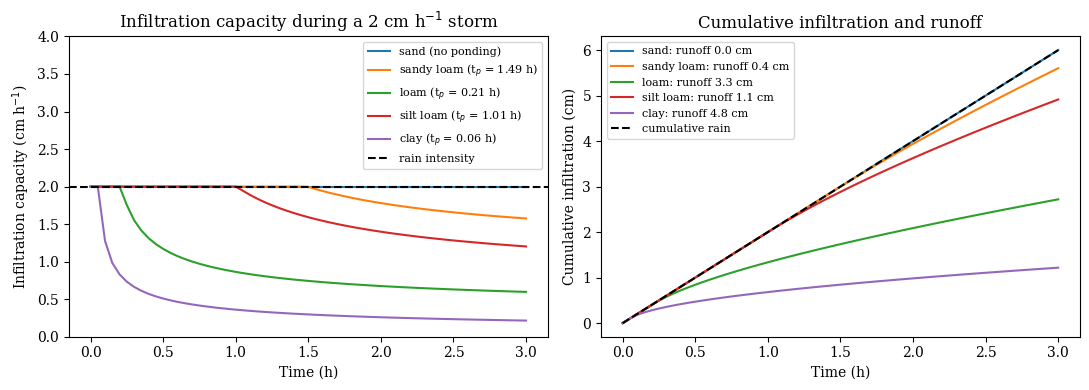

In [3]:
def green_ampt(i_cm_h, duration_h, psi_f, Ks, theta_s, theta_i, dt_h=0.05):
    """Infiltration for constant rain intensity i (cm/h). Returns a DataFrame with time, f, F, runoff."""
    dtheta = theta_s - theta_i
    S = psi_f * dtheta                                   # suction-storage product (cm)
    t = np.arange(0, duration_h + dt_h, dt_h)
    F = np.zeros_like(t); f = np.zeros_like(t)
    if i_cm_h <= Ks:                                     # never ponds
        F = i_cm_h * t; f[:] = i_cm_h
        tp = np.inf
    else:
        Fp = Ks * S / (i_cm_h - Ks); tp = Fp / i_cm_h
        rhs0 = Fp - S * np.log(1 + Fp / S)
        for k, tk in enumerate(t):
            if tk <= tp:
                F[k] = i_cm_h * tk; f[k] = i_cm_h
            else:
                g = lambda Fk: Fk - S * np.log(1 + Fk / S) - (Ks * (tk - tp) + rhs0)
                F[k] = brentq(g, Fp, Fp + i_cm_h * (tk - tp) + 1e-9)
                f[k] = Ks * (1 + S / F[k])
    runoff_rate = np.clip(i_cm_h - f, 0, None)
    return pd.DataFrame({'t_h': t, 'f_cm_h': f, 'F_cm': F, 'runoff_cm_h': runoff_rate}), tp

i_rain, dur = 2.0, 3.0            # 2 cm/h for 3 hours (a heavy storm, 60 mm)
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for soil in ['sand', 'sandy loam', 'loam', 'silt loam', 'clay']:
    p = ga.loc[soil]
    res, tp = green_ampt(i_rain, dur, p['psi_f'], p['Ks'], p['theta_s'], theta_i=0.5 * p['theta_s'])
    total_runoff = np.trapezoid(res['runoff_cm_h'], res['t_h'])
    axs[0].plot(res['t_h'], res['f_cm_h'], label=f'{soil} (t$_p$ = {tp:.2f} h)' if np.isfinite(tp) else f'{soil} (no ponding)')
    axs[1].plot(res['t_h'], res['F_cm'], label=f'{soil}: runoff {total_runoff:.1f} cm')
axs[0].axhline(i_rain, color='k', ls='--', label='rain intensity'); axs[0].set_ylim(0, 4)
axs[0].set_xlabel('Time (h)'); axs[0].set_ylabel('Infiltration capacity (cm h$^{-1}$)'); axs[0].legend(fontsize=8)
axs[1].plot([0, dur], [0, i_rain * dur], 'k--', label='cumulative rain'); axs[1].set_xlabel('Time (h)'); axs[1].set_ylabel('Cumulative infiltration (cm)'); axs[1].legend(fontsize=8)
axs[0].set_title('Infiltration capacity during a 2 cm h$^{-1}$ storm'); axs[1].set_title('Cumulative infiltration and runoff'); plt.tight_layout()

**What to notice.** Sand never ponds at this intensity; all 6 cm of rain infiltrates. Clay ponds within minutes and
most of the rain runs off. Loam and silt loam are in between: they absorb the first part of the storm and then produce
runoff once the wetting front has advanced. Initial soil moisture matters too: try a wetter initial state in the exercises.

## **Step 3: Water retention curves**

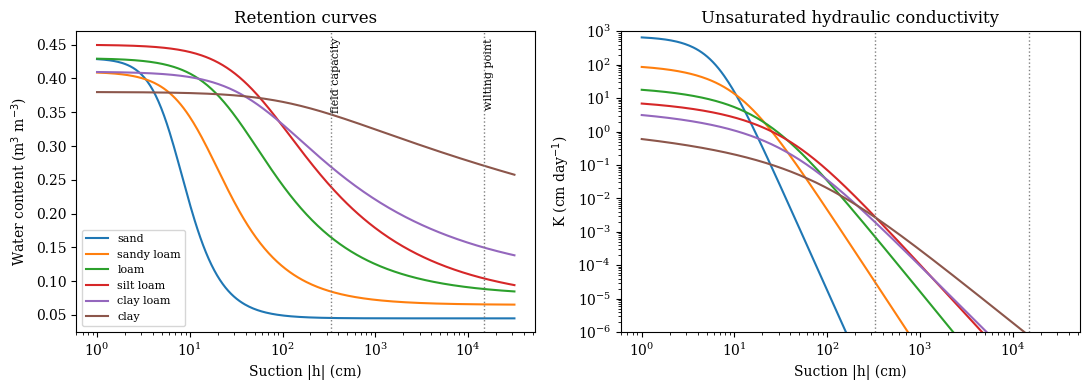

In [4]:
def theta_vg(h_cm, p):
    m = 1 - 1 / p['n']
    return p['theta_r'] + (p['theta_s'] - p['theta_r']) / (1 + (p['alpha'] * np.abs(h_cm)) ** p['n']) ** m

def K_vg(h_cm, p, l=0.5):
    m = 1 - 1 / p['n']
    Se = (theta_vg(h_cm, p) - p['theta_r']) / (p['theta_s'] - p['theta_r'])
    return p['Ks'] * Se ** l * (1 - (1 - Se ** (1 / m)) ** m) ** 2

h = -np.logspace(0, 4.5, 300)         # 1 cm to ~30,000 cm suction
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for soil in ['sand', 'sandy loam', 'loam', 'silt loam', 'clay loam', 'clay']:
    p = vg.loc[soil]
    axs[0].semilogx(-h, theta_vg(h, p), label=soil)
    axs[1].loglog(-h, K_vg(h, p), label=soil)
for ax in axs:
    ax.axvline(330, color='grey', ls=':', lw=1); ax.axvline(15000, color='grey', ls=':', lw=1)
axs[0].text(330, 0.46, 'field capacity', rotation=90, va='top', fontsize=8); axs[0].text(15000, 0.46, 'wilting point', rotation=90, va='top', fontsize=8)
axs[0].set_xlabel('Suction |h| (cm)'); axs[0].set_ylabel('Water content (m$^3$ m$^{-3}$)'); axs[0].set_title('Retention curves'); axs[0].legend(fontsize=8)
axs[1].set_xlabel('Suction |h| (cm)'); axs[1].set_ylabel('K (cm day$^{-1}$)'); axs[1].set_title('Unsaturated hydraulic conductivity'); axs[1].set_ylim(1e-6, 1e3)
plt.tight_layout()

Sand drains quickly: its water content drops sharply at low suction, and its conductivity falls by orders of magnitude
as it dries. Clay holds water at high suction but conducts it slowly even when wet. Note that sand has the highest $K_s$
but, at a suction of 1000 cm, it is drier and *less* conductive than clay. This reversal is why water can move from a
wet sand into a clay layer, not the other way round, and why roots in sand feel drought sooner.

## **Step 4: Plant-available water**

Field capacity is taken at $h = -100$ cm for sand and loamy sand and at $-330$ cm for the finer soils, the usual convention; wilting point at $-15{,}000$ cm.

            theta_s  field capacity  wilting point  available water  \
soil                                                                  
sand           0.43           0.049          0.045            0.004   
loamy sand     0.41           0.071          0.057            0.014   
sandy loam     0.41           0.085          0.066            0.019   
loam           0.43           0.165          0.088            0.077   
silt loam      0.45           0.240          0.104            0.136   
clay loam      0.41           0.270          0.150            0.120   
clay           0.38           0.347          0.271            0.076   

            AWC in 1 m (mm)  
soil                         
sand                  4.306  
loamy sand           14.018  
sandy loam           19.154  
loam                 76.992  
silt loam           136.299  
clay loam           120.086  
clay                 76.259  


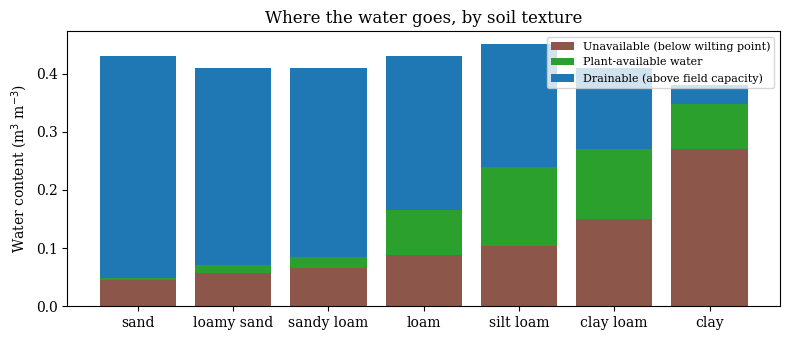

In [5]:
rows = []
for soil in vg.index:
    p = vg.loc[soil]
    h_fc = -100 if soil in ('sand', 'loamy sand') else -330     # coarse soils drain to field capacity at lower suction
    fc = theta_vg(h_fc, p); wp = theta_vg(-15000, p)
    rows.append({'soil': soil, 'theta_s': p['theta_s'], 'field capacity': fc, 'wilting point': wp, 'available water': fc - wp,
                 'AWC in 1 m (mm)': (fc - wp) * 1000})
paw = pd.DataFrame(rows).set_index('soil').round(3)
print(paw)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(paw.index, paw['wilting point'], label='Unavailable (below wilting point)', color='tab:brown')
ax.bar(paw.index, paw['available water'], bottom=paw['wilting point'], label='Plant-available water', color='tab:green')
ax.bar(paw.index, paw['theta_s'] - paw['field capacity'], bottom=paw['field capacity'], label='Drainable (above field capacity)', color='tab:blue')
ax.set_ylabel('Water content (m$^3$ m$^{-3}$)'); ax.legend(fontsize=8); ax.set_title('Where the water goes, by soil texture'); plt.tight_layout()

Loams hold the most plant-available water. Sand drains most of what it receives; clay holds a lot of water, but much
of it is held too tightly for plants. This single number, available water capacity in the root zone, controls how many
dry days a crop or grassland can survive, which is the subject of the next tutorial.

## **Exercises**

**Exercise 1.** Rerun the Green-Ampt storm with the soil initially at field capacity (`theta_i = theta_fc`) instead of half saturation. How much earlier does loam pond, and how much more runoff is produced?

**Exercise 2.** Rain intensities in the southeastern United States often exceed 5 cm h$^{-1}$ for short periods. Run a 30-minute storm at 5 cm h$^{-1}$ and a 3-hour storm at 0.8 cm h$^{-1}$ (both about 24 mm). Which produces more runoff on loam, and why?

**Exercise 3.** Field capacity is sometimes defined at $h = -100$ cm for sandy soils. Recompute available water for sand with that definition and comment on how much the choice matters.

**Exercise 4.** Implement the Horton infiltration model, $f = f_c + (f_0 - f_c) e^{-kt}$, and fit $f_0$, $f_c$, $k$ to the Green-Ampt loam curve after ponding. Where do the two models disagree most?

## **References**

- Green, W. H., & Ampt, G. A. (1911). Studies on soil physics. *Journal of Agricultural Science*, 4, 1-24.
- van Genuchten, M. Th. (1980). A closed-form equation for predicting the hydraulic conductivity of unsaturated soils. *Soil Science Society of America Journal*, 44, 892-898.
- Rawls, W. J., Brakensiek, D. L., & Miller, N. (1983). Green-Ampt infiltration parameters from soils data. *Journal of Hydraulic Engineering*, 109, 62-70.
- Carsel, R. F., & Parrish, R. S. (1988). Developing joint probability distributions of soil water retention characteristics. *Water Resources Research*, 24, 755-769.
- Dingman, S. L. (2015). *Physical Hydrology*, 3rd ed., Chapters 7-8.